# Umubyeyi: Kinyarwanda maternal-wellness intent classification

End-to-end notebook: load and clean the data, explore it, then train and compare a Complement Naive Bayes baseline, classical models (Logistic Regression, Linear SVM, Random Forest), and an AfriBERTa fine-tune as a negative-result check. Set the runtime to GPU (Runtime > Change runtime type > T4 GPU) and Run all. All metrics and figures are saved under reports/ and bundled into a downloadable zip at the end.

## Setup

In [1]:
!pip install -q -U transformers datasets accelerate sentence-transformers scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 118.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 18.0 MB/s eta 0:00:00


In [2]:
import warnings, os, re, json
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

sns.set_theme(style="whitegrid")
RNG = 42
np.random.seed(RNG); torch.manual_seed(RNG)
TEAL, CORAL, SAND = "#2A9D8F", "#E76F51", "#E9C46A"
PALETTE = ["#2A9D8F", "#E76F51", "#E9C46A", "#264653", "#8AB17D", "#F4A261"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE if DEVICE == "cuda" else "CPU (set the runtime to T4 GPU for Model 3)")

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

REPORTS = "reports"; FIGURES = os.path.join(REPORTS, "figures")
os.makedirs(FIGURES, exist_ok=True)
def save_json(name, payload):
    with open(os.path.join(REPORTS, name), "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)
    print("saved", os.path.join(REPORTS, name))
def save_fig(name):
    plt.savefig(os.path.join(FIGURES, name), dpi=150, bbox_inches="tight")

RAW_URL = "https://raw.githubusercontent.com/IrutingaboRaissa/UMUBYEYI/main/data/raw/amod_full.csv"
KIN_URL = "https://raw.githubusercontent.com/IrutingaboRaissa/UMUBYEYI/main/notebooks/amod_kinyarwanda.csv"

def score(yt, yp):
    pr, rc, f1, _ = precision_recall_fscore_support(yt, yp, average="macro", zero_division=0)
    return {"accuracy": round(float(accuracy_score(yt, yp)), 4), "precision_macro": round(float(pr), 4),
            "recall_macro": round(float(rc), 4), "f1_macro": round(float(f1), 4)}
results = {}

device: cuda


## 1. Load the data

The classifier is trained on the Amod mental-health counseling dataset: real question-and-answer pairs between people and licensed counselors. The question (Context) is the input.

In [3]:
df = pd.read_csv(RAW_URL)
df.columns = [c.strip() for c in df.columns]
print(f"loaded {len(df):,} rows | columns: {list(df.columns)}")
df.head(3)

loaded 3,512 rows | columns: ['Context', 'Response']


                                             Context  \
0  I'm going through some things with my feelings...   
1  I'm going through some things with my feelings...   
2  I'm going through some things with my feelings...   

                                            Response  
0  If everyone thinks you're worthless, then mayb...  
1  Hello, and thank you for your question and see...  
2  First thing I'd suggest is getting the sleep y...  

## 2. Cleaning

Trim whitespace, drop empty rows, and add simple length features (word and character counts) used in the checks below.

In [4]:
for c in ["Context", "Response"]:
    df[c] = df[c].astype(str).str.strip()
before = len(df)
df = df[(df["Context"].str.len() > 0) & (df["Response"].str.len() > 0)].copy()
print(f"dropped {before - len(df)} empty rows -> {len(df):,} remain")

word_count = lambda t: len(re.findall(r"\b\w+\b", str(t)))
df["ctx_words"] = df["Context"].map(word_count)
df["resp_words"] = df["Response"].map(word_count)
df["ctx_chars"] = df["Context"].str.len()
df["resp_chars"] = df["Response"].str.len()
df[["ctx_words", "resp_words", "ctx_chars", "resp_chars"]].describe().round(1)

dropped 0 empty rows -> 3,512 remain


       ctx_words  resp_words  ctx_chars  resp_chars
count     3512.0      3512.0     3512.0      3512.0
mean        57.5       183.5      282.5      1025.7
std         50.2       129.3      246.1      1010.6
min          5.0         1.0       24.0         1.0
25%         30.0        98.0      147.0       532.0
50%         48.0       150.0      232.0       836.0
75%         71.0       229.0      348.2      1270.2
max        556.0      2043.0     2702.0     32739.0

## 3. Deduplicate

For intent classification the input is the question alone, and the same question appears several times with different counselor answers. We de-duplicate on the question so none is counted twice.

In [5]:
print(f"total rows ........ {len(df):,}")
print(f"unique questions .. {df['Context'].nunique():,}")
print(f"duplicate rows .... {df['Context'].duplicated().sum():,}")
dfu = df.drop_duplicates(subset="Context", keep="first").reset_index(drop=True)
print(f"\nunique-question dataset: {len(dfu):,} rows")

total rows ........ 3,512
unique questions .. 995
duplicate rows .... 2,517

unique-question dataset: 995 rows


## 4. Intent labeling

Each question is mapped to one of six maternal-wellness intents with a keyword lexicon (ordered rare to common so ties favor rarer intents). Questions with no keyword match, or that mention out-of-scope clinical topics, are dropped.

In [6]:
INTENT_KEYWORDS = {
    "self_care_coping":     ["self-care", "self care", "coping", "cope", "manage", "routine", "advice", "what can i do", "take care"],
    "sleep":                ["sleep", "insomnia", "tired", "exhaust", "awake", "rest", "fatigue"],
    "overwhelmed_identity": ["overwhelm", "myself", "identity", "lost", "failing", "failure", "too much", "can't handle"],
    "sadness_low_mood":     ["sad", "depress", "empty", "hopeless", "tearful", "cry", "worthless", "down", "numb", "miserable"],
    "anxiety_worry":        ["anxi", "worry", "worried", "panic", "afraid", "fear", "nervous", "scared", "stress"],
    "relationship_support": ["partner", "husband", "wife", "family", "relationship", "alone", "lonely", "support", "marriage", "friend"],
}
EXCLUDE = ["childhood trauma", "addict", "alcohol", "drug", "eating disorder", "anorexia", "bulimia",
           "ptsd", "flashback", "personality disorder", "schizophren", "bipolar"]

ctx = dfu["Context"].str.lower()
intent_names = list(INTENT_KEYWORDS)
hits = pd.DataFrame({i: ctx.str.contains("|".join(re.escape(k) for k in kws), regex=True)
                     for i, kws in INTENT_KEYWORDS.items()}).astype(int)
dfu["excluded"] = ctx.str.contains("|".join(re.escape(k) for k in EXCLUDE), regex=True)
dfu["n_intents"] = hits.sum(axis=1)
dfu["intent"] = [intent_names[j] for j in hits.values.argmax(axis=1)]
dfu.loc[(dfu["n_intents"] == 0) | (dfu["excluded"]), "intent"] = np.nan

data = dfu.dropna(subset=["intent"]).reset_index(drop=True)
print(f"labeled, in-scope dataset: {len(data):,} questions across {data['intent'].nunique()} intents\n")
dist = data["intent"].value_counts()
print(dist.to_string())
print(f"\nimbalance ratio (max/min): {dist.max() / dist.min():.1f}x  -> macro-F1 is the headline metric")

labeled, in-scope dataset: 724 questions across 6 intents

intent
relationship_support    230
overwhelmed_identity    137
sadness_low_mood        121
sleep                    84
self_care_coping         76
anxiety_worry            76

imbalance ratio (max/min): 3.0x  -> macro-F1 is the headline metric


## 5. Visualizations

Class balance, question length, and the most distinctive words per intent.

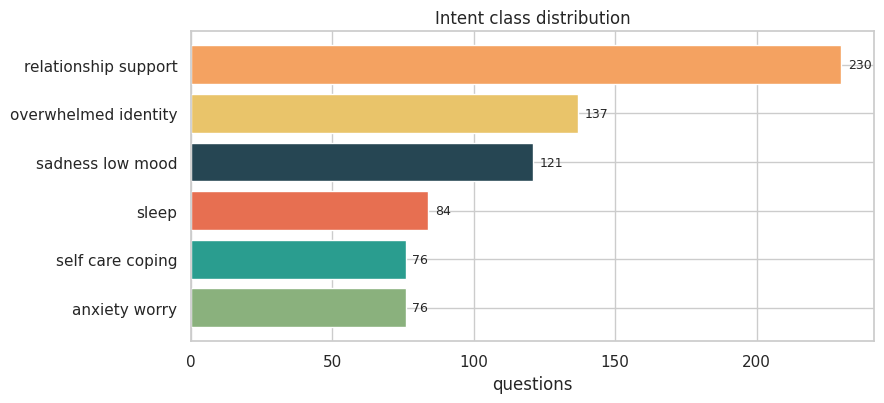

In [7]:
order = dist.sort_values().index
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(range(len(order)), dist[order].values, color=[PALETTE[intent_names.index(i)] for i in order])
ax.set_yticks(range(len(order))); ax.set_yticklabels([i.replace("_", " ") for i in order])
for yloc, v in enumerate(dist[order].values):
    ax.text(v + dist.max() * 0.01, yloc, f"{v}", va="center", fontsize=9)
ax.set_title("Intent class distribution"); ax.set_xlabel("questions")
plt.tight_layout(); save_fig("class_balance.png"); plt.show()

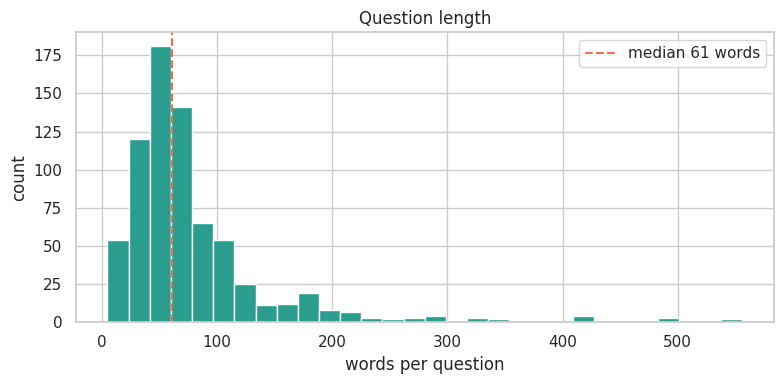

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(data["ctx_words"], bins=30, color=TEAL, edgecolor="white")
ax.axvline(data["ctx_words"].median(), color=CORAL, linestyle="--", label=f"median {int(data['ctx_words'].median())} words")
ax.set_xlabel("words per question"); ax.set_ylabel("count"); ax.set_title("Question length"); ax.legend()
plt.tight_layout(); save_fig("question_length.png"); plt.show()

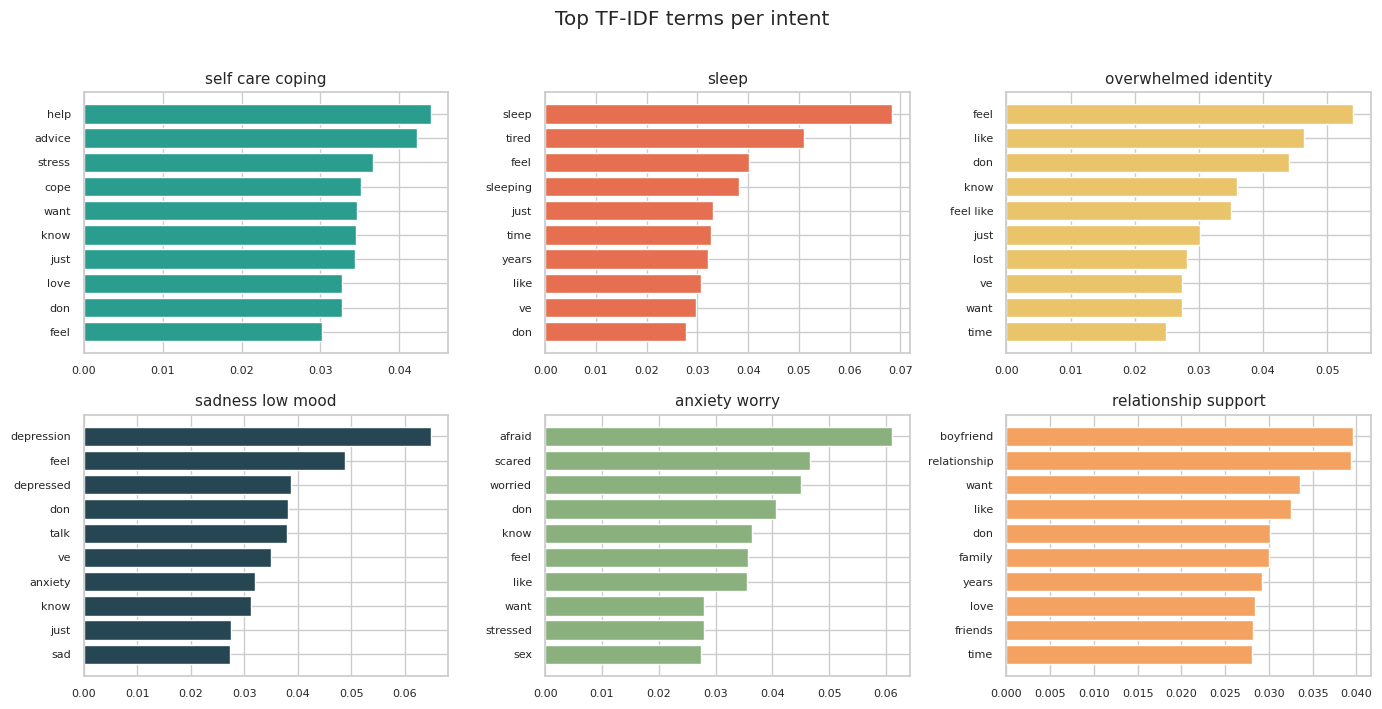

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
viz_tfidf = TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=3, max_features=4000, sublinear_tf=True)
Xv = viz_tfidf.fit_transform(data["Context"])
terms = np.array(viz_tfidf.get_feature_names_out())
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, intent in zip(axes.ravel(), intent_names):
    mask = (data["intent"] == intent).values
    mean_tfidf = np.asarray(Xv[mask].mean(axis=0)).ravel()
    top = mean_tfidf.argsort()[-10:]
    ax.barh(terms[top], mean_tfidf[top], color=PALETTE[intent_names.index(intent)])
    ax.set_title(intent.replace("_", " "), fontsize=11); ax.tick_params(labelsize=8)
fig.suptitle("Top TF-IDF terms per intent", y=1.01)
plt.tight_layout(); save_fig("top_terms.png"); plt.show()

## 6. Add Kinyarwanda text

Models 2 and 3 work directly in Kinyarwanda. The questions were translated once with NLLB-200 and cached; we merge that translation onto the labeled rows.

In [10]:
kin = pd.read_csv(KIN_URL)
data = data.merge(kin[["Context", "context_rw"]], on="Context", how="inner").reset_index(drop=True)
labels = sorted(data["intent"].unique())
l2i = {l: i for i, l in enumerate(labels)}
y = data["intent"].values
yi = data["intent"].map(l2i).values
EN = data["Context"].values
RW = data["context_rw"].values
print(f"modeling dataset: {len(data):,} rows with English + Kinyarwanda + intent")

modeling dataset: 724 rows with English + Kinyarwanda + intent


## 7. Train and test split

A stratified 80/20 split, shared across all models so the comparison is fair.

In [11]:
idx = np.arange(len(data))
tr, te = train_test_split(idx, test_size=0.20, random_state=RNG, stratify=y)
print("train:", len(tr), "| test:", len(te))

train: 579 | test: 145


## 8. Baseline: Complement Naive Bayes (English TF-IDF)

A simple reference the real models must beat.

In [12]:
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import FeatureUnion
# word n-grams + character n-grams; char_wb captures sub-word morphology (helps both languages)
tfidf_en = FeatureUnion([
    ("word", TfidfVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2, max_features=8000, sublinear_tf=True)),
    ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True)),
])
Xtr = tfidf_en.fit_transform(EN[tr]); Xte = tfidf_en.transform(EN[te])
nb = ComplementNB().fit(Xtr, y[tr])
results["Baseline (ComplementNB)"] = score(y[te], nb.predict(Xte))
print("Baseline (ComplementNB):", results["Baseline (ComplementNB)"])
save_json("naive_bayes_baseline.json", {"ComplementNB (baseline)": results["Baseline (ComplementNB)"]})

Baseline (ComplementNB): {'accuracy': 0.531, 'precision_macro': 0.7503, 'recall_macro': 0.4213, 'f1_macro': 0.465}
saved reports/naive_bayes_baseline.json


## 9. Model 1: TF-IDF + Logistic Regression (English)

The deployed model: linear, class-weighted, interpretable. Features are **word + character n-grams** (char n-grams capture sub-word morphology and lift macro-F1).

In [13]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RNG).fit(Xtr, y[tr])
p1 = clf.predict(Xte)
results["Model 1: TF-IDF + LogReg (English)"] = score(y[te], p1)
print("Model 1:", results["Model 1: TF-IDF + LogReg (English)"], "\n")
print(classification_report(y[te], p1, zero_division=0))
save_json("baseline_metrics.json", {"Logistic Regression": results["Model 1: TF-IDF + LogReg (English)"]})

Model 1: {'accuracy': 0.6621, 'precision_macro': 0.7028, 'recall_macro': 0.6189, 'f1_macro': 0.6483} 

                      precision    recall  f1-score   support

       anxiety_worry       0.69      0.60      0.64        15
overwhelmed_identity       0.70      0.57      0.63        28
relationship_support       0.61      0.87      0.71        46
    sadness_low_mood       0.60      0.50      0.55        24
    self_care_coping       0.70      0.47      0.56        15
               sleep       0.92      0.71      0.80        17

            accuracy                           0.66       145
           macro avg       0.70      0.62      0.65       145
        weighted avg       0.68      0.66      0.66       145

saved reports/baseline_metrics.json


## 10. Model 2: Linear SVM (English)

A linear support-vector classifier on the same word + character n-grams — a classic strong model for short, sparse text.

In [14]:
from sklearn.svm import LinearSVC
svm = LinearSVC(class_weight="balanced", random_state=RNG).fit(Xtr, y[tr])
p2 = svm.predict(Xte)
results["Model 2: Linear SVM (English)"] = score(y[te], p2)
print("Model 2:", results["Model 2: Linear SVM (English)"], "\n")
print(classification_report(y[te], p2, zero_division=0))
save_json("linear_svm_metrics.json", {"Model 2: Linear SVM (English)": results["Model 2: Linear SVM (English)"]})

Model 2: {'accuracy': 0.6897, 'precision_macro': 0.7188, 'recall_macro': 0.6414, 'f1_macro': 0.6688} 

                      precision    recall  f1-score   support

       anxiety_worry       0.69      0.60      0.64        15
overwhelmed_identity       0.78      0.64      0.71        28
relationship_support       0.63      0.89      0.74        46
    sadness_low_mood       0.65      0.54      0.59        24
    self_care_coping       0.70      0.47      0.56        15
               sleep       0.86      0.71      0.77        17

            accuracy                           0.69       145
           macro avg       0.72      0.64      0.67       145
        weighted avg       0.70      0.69      0.68       145

saved reports/linear_svm_metrics.json


## 11. Model 3: Random Forest (English)

An ensemble of decision trees on the same features — the best-performing classical model on this data.

Model 3: {'accuracy': 0.7172, 'precision_macro': 0.8038, 'recall_macro': 0.6582, 'f1_macro': 0.7045} 

                      precision    recall  f1-score   support

       anxiety_worry       0.73      0.53      0.62        15
overwhelmed_identity       0.83      0.68      0.75        28
relationship_support       0.62      0.96      0.75        46
    sadness_low_mood       0.65      0.54      0.59        24
    self_care_coping       1.00      0.53      0.70        15
               sleep       1.00      0.71      0.83        17

            accuracy                           0.72       145
           macro avg       0.80      0.66      0.70       145
        weighted avg       0.76      0.72      0.71       145



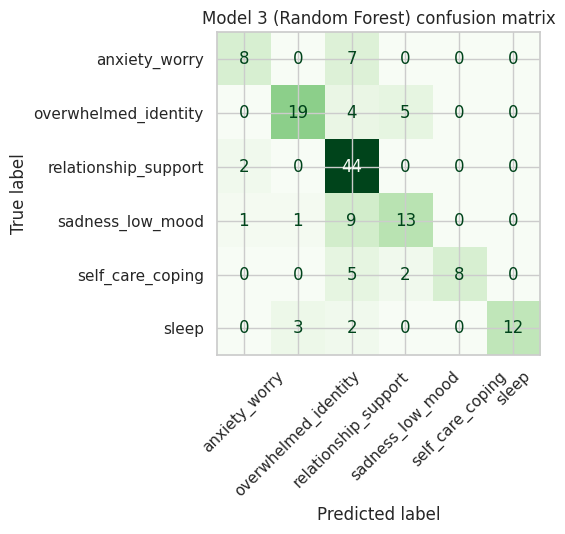

saved reports/random_forest_metrics.json


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RNG).fit(Xtr, y[tr])
p3 = rf.predict(Xte)
results["Model 3: Random Forest (English)"] = score(y[te], p3)
print("Model 3:", results["Model 3: Random Forest (English)"], "\n")
print(classification_report(y[te], p3, zero_division=0))
cm = confusion_matrix(y[te], p3, labels=labels)
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Greens", ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title("Model 3 (Random Forest) confusion matrix"); plt.tight_layout(); save_fig("random_forest_confusion.png"); plt.show()
save_json("random_forest_metrics.json", {"Model 3: Random Forest (English)": results["Model 3: Random Forest (English)"]})

## 12. Model 4: AfriBERTa fine-tune (Kinyarwanda)

AfriBERTa (Ogueji et al., 2021, *Small Data? No Problem!*) is pretrained on 11 African languages including Kinyarwanda, and is small (~126M) so it fits our small dataset better than XLM-R. Unlike Model 3, this is trained with a validation split and **early stopping over up to 15 epochs**, and we plot the learning curve to show whether more training helps or the model is data-limited.

config.json:   0%|          | 0.00/729 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/257 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/1.55M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/446M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/133 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: castorini/afriberta_base
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.decoder.bias       | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.decoder.weight     | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/446M [00:00<?, ?B/s]

epoch  1/15  train_loss=1.793  val_loss=1.788  val_f1=0.113
epoch  2/15  train_loss=1.751  val_loss=1.765  val_f1=0.105
epoch  3/15  train_loss=1.599  val_loss=1.698  val_f1=0.271
epoch  4/15  train_loss=1.419  val_loss=1.662  val_f1=0.323
epoch  5/15  train_loss=1.119  val_loss=1.630  val_f1=0.358
epoch  6/15  train_loss=0.828  val_loss=1.564  val_f1=0.402
epoch  7/15  train_loss=0.535  val_loss=1.624  val_f1=0.433
epoch  8/15  train_loss=0.338  val_loss=1.700  val_f1=0.479
epoch  9/15  train_loss=0.233  val_loss=1.747  val_f1=0.393
epoch 10/15  train_loss=0.169  val_loss=1.819  val_f1=0.440
epoch 11/15  train_loss=0.126  val_loss=1.903  val_f1=0.407
early stopping at epoch 11 (best val macro-F1=0.479)


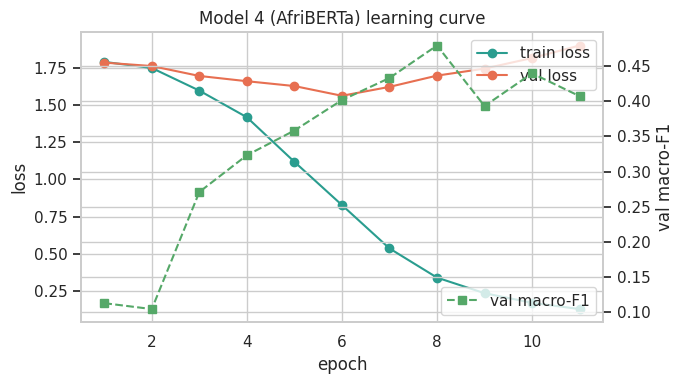


Model 4: {'accuracy': 0.4759, 'precision_macro': 0.478, 'recall_macro': 0.4373, 'f1_macro': 0.4405} 

                      precision    recall  f1-score   support

       anxiety_worry       0.73      0.53      0.62        15
overwhelmed_identity       0.30      0.21      0.25        28
relationship_support       0.58      0.74      0.65        46
    sadness_low_mood       0.67      0.33      0.44        24
    self_care_coping       0.25      0.33      0.29        15
               sleep       0.35      0.47      0.40        17

            accuracy                           0.48       145
           macro avg       0.48      0.44      0.44       145
        weighted avg       0.49      0.48      0.47       145

saved reports/afriberta_finetune_metrics.json


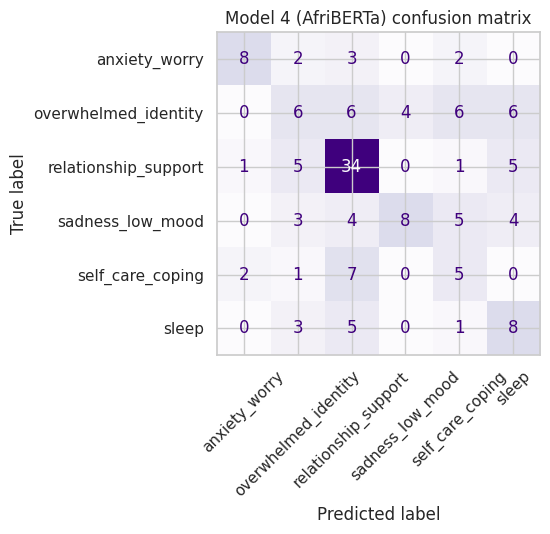

In [16]:
# Model 4: AfriBERTa fine-tune (Kinyarwanda) -- proper training with validation,
# early stopping, and a learning curve (directly addresses "trained too short").
import copy
from torch.utils.data import DataLoader, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

A_MODEL = "castorini/afriberta_base"
A_MAXLEN, A_BATCH, A_EPOCHS, A_LR, PATIENCE = 128, 16, 15, 2e-5, 3
a_tok = AutoTokenizer.from_pretrained(A_MODEL)
a_tok.model_max_length = A_MAXLEN
a_model = AutoModelForSequenceClassification.from_pretrained(A_MODEL, num_labels=len(labels)).to(DEVICE)

class AfriDS(Dataset):
    def __init__(self, texts, ys):
        self.enc = a_tok(list(texts), truncation=True, padding="max_length", max_length=A_MAXLEN, return_tensors="pt")
        self.y = torch.tensor(list(ys))
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item["labels"] = self.y[i]
        return item

# carve a validation set out of the TRAIN indices; the test set stays untouched
tr_sub, val_sub = train_test_split(tr, test_size=0.15, stratify=yi[tr], random_state=RNG)
counts = np.bincount(yi[tr_sub], minlength=len(labels)); counts[counts == 0] = 1
weights = torch.tensor(counts.sum() / (len(labels) * counts), dtype=torch.float).to(DEVICE)
loss_fn = torch.nn.CrossEntropyLoss(weight=weights)

train_dl = DataLoader(AfriDS(RW[tr_sub], yi[tr_sub]), batch_size=A_BATCH, shuffle=True)
val_dl = DataLoader(AfriDS(RW[val_sub], yi[val_sub]), batch_size=32)
optimizer = torch.optim.AdamW(a_model.parameters(), lr=A_LR, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(optimizer, int(0.1 * len(train_dl) * A_EPOCHS), len(train_dl) * A_EPOCHS)

def a_evaluate(dl):
    a_model.eval(); loss_tot, preds, gold = 0.0, [], []
    with torch.no_grad():
        for batch in dl:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = a_model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
            loss_tot += loss_fn(out.logits, batch["labels"]).item()
            preds += out.logits.argmax(-1).cpu().tolist(); gold += batch["labels"].cpu().tolist()
    return loss_tot / len(dl), f1_score(gold, preds, average="macro")

history, best_f1, best_state, wait = [], -1.0, None, 0
for epoch in range(A_EPOCHS):
    a_model.train(); total = 0.0
    for batch in train_dl:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad()
        out = a_model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
        loss = loss_fn(out.logits, batch["labels"])
        loss.backward(); optimizer.step(); scheduler.step(); total += loss.item()
    tr_loss = total / len(train_dl)
    val_loss, val_f1 = a_evaluate(val_dl)
    history.append({"epoch": epoch + 1, "train_loss": tr_loss, "val_loss": val_loss, "val_f1": val_f1})
    print(f"epoch {epoch + 1:2d}/{A_EPOCHS}  train_loss={tr_loss:.3f}  val_loss={val_loss:.3f}  val_f1={val_f1:.3f}")
    if val_f1 > best_f1:
        best_f1, best_state, wait = val_f1, copy.deepcopy(a_model.state_dict()), 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"early stopping at epoch {epoch + 1} (best val macro-F1={best_f1:.3f})"); break

a_model.load_state_dict(best_state)  # restore the best checkpoint

# learning curve -- shows whether longer training helps or plateaus (data-limited)
h = pd.DataFrame(history)
fig, ax1 = plt.subplots(figsize=(7, 4))
ax1.plot(h["epoch"], h["train_loss"], color=TEAL, marker="o", label="train loss")
ax1.plot(h["epoch"], h["val_loss"], color=CORAL, marker="o", label="val loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(loc="upper right")
ax2 = ax1.twinx(); ax2.plot(h["epoch"], h["val_f1"], "g--", marker="s", label="val macro-F1")
ax2.set_ylabel("val macro-F1"); ax2.legend(loc="lower right")
ax1.set_title("Model 4 (AfriBERTa) learning curve"); plt.tight_layout()
save_fig("model4_learning_curve.png"); plt.show()

# final evaluation on the held-out test set
a_model.eval(); preds = []
for batch in DataLoader(AfriDS(RW[te], yi[te]), batch_size=32):
    batch = {k: v.to(DEVICE) for k, v in batch.items()}
    with torch.no_grad():
        preds += a_model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"]).logits.argmax(-1).cpu().tolist()
results["Model 4: AfriBERTa fine-tune (Kinyarwanda)"] = score(yi[te], preds)
print("\nModel 4:", results["Model 4: AfriBERTa fine-tune (Kinyarwanda)"], "\n")
print(classification_report(yi[te], preds, target_names=labels, zero_division=0))
save_json("afriberta_finetune_metrics.json", {"Model 4: AfriBERTa fine-tune (Kinyarwanda)": results["Model 4: AfriBERTa fine-tune (Kinyarwanda)"]})

cm = confusion_matrix(yi[te], preds, labels=list(range(len(labels))))
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay(cm, display_labels=labels).plot(cmap="Purples", ax=ax, colorbar=False, xticks_rotation=45)
ax.set_title("Model 4 (AfriBERTa) confusion matrix")
plt.tight_layout(); save_fig("model4_confusion.png"); plt.show()

## 13. Model comparison

                                            Accuracy      F1
Baseline (ComplementNB)                       0.5310  0.4650
Model 1: TF-IDF + LogReg (English)            0.6621  0.6483
Model 2: Linear SVM (English)                 0.6897  0.6688
Model 3: Random Forest (English)              0.7172  0.7045
Model 4: AfriBERTa fine-tune (Kinyarwanda)    0.4759  0.4405


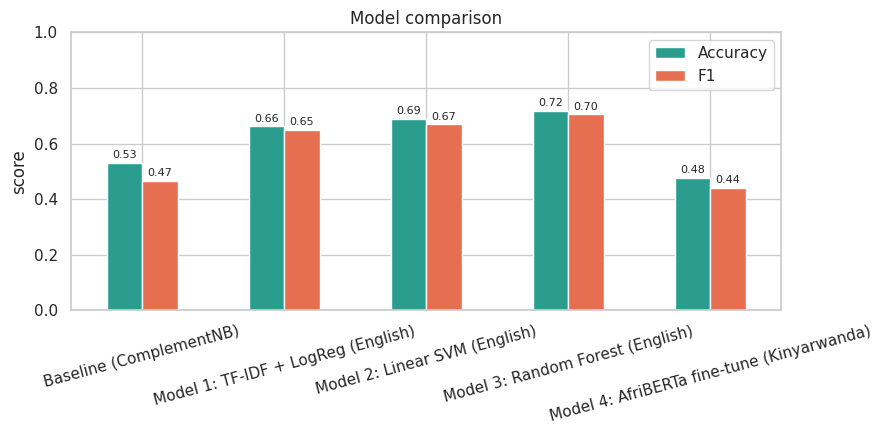

In [17]:
comparison = pd.DataFrame({k: {"Accuracy": v["accuracy"], "F1": v["f1_macro"]} for k, v in results.items()}).T
print(comparison.to_string())
comparison.to_csv(os.path.join(REPORTS, "model_comparison.csv"))
ax = comparison.plot.bar(figsize=(9, 4.5), rot=15, color=[TEAL, CORAL], edgecolor="white")
ax.set_ylim(0, 1.0); ax.set_ylabel("score"); ax.set_title("Model comparison")
for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=8, padding=2)
plt.tight_layout(); save_fig("model_comparison.png"); plt.show()

## 13. Cross-lingual degradation

Holding the model fixed, how much accuracy does the move to machine-translated Kinyarwanda cost? This gap is the central measurement.

English:     acc=0.739  F1=0.719
Kinyarwanda: acc=0.591  F1=0.559
Degradation: dF1=+0.160 (22% relative)
saved reports/cross_lingual_degradation.json


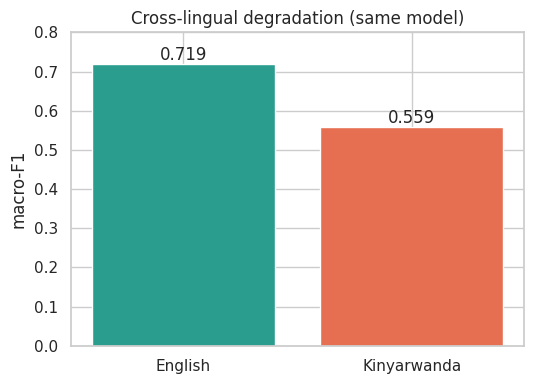

In [18]:
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.model_selection import cross_validate, StratifiedKFold
cv = StratifiedKFold(5, shuffle=True, random_state=RNG)
def cross_lingual_f1(stop_words, column):
    pipe = Pipeline([
        ("feats", FeatureUnion([
            ("word", TfidfVectorizer(stop_words=stop_words, ngram_range=(1, 2), min_df=2, max_features=8000, sublinear_tf=True)),
            ("char", TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, sublinear_tf=True)),
        ])),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RNG)),
    ])
    r = cross_validate(pipe, data[column], y, cv=cv, scoring=["accuracy", "f1_macro"])
    return r["test_accuracy"].mean(), r["test_f1_macro"].mean()

en_acc, en_f1 = cross_lingual_f1("english", "Context")
rw_acc, rw_f1 = cross_lingual_f1(None, "context_rw")
print(f"English:     acc={en_acc:.3f}  F1={en_f1:.3f}")
print(f"Kinyarwanda: acc={rw_acc:.3f}  F1={rw_f1:.3f}")
print(f"Degradation: dF1={en_f1 - rw_f1:+.3f} ({(1 - rw_f1 / en_f1) * 100:.0f}% relative)")
save_json("cross_lingual_degradation.json", {
    "english": {"accuracy": round(float(en_acc), 4), "f1_macro": round(float(en_f1), 4)},
    "kinyarwanda_mt": {"accuracy": round(float(rw_acc), 4), "f1_macro": round(float(rw_f1), 4)},
    "delta_f1_macro": round(float(en_f1 - rw_f1), 4)})
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.bar(["English", "Kinyarwanda"], [en_f1, rw_f1], color=[TEAL, CORAL])
ax.set_ylabel("macro-F1"); ax.set_ylim(0, 0.8); ax.set_title("Cross-lingual degradation (same model)")
for i, value in enumerate([en_f1, rw_f1]):
    ax.text(i, value + 0.01, f"{value:.3f}", ha="center")
plt.tight_layout(); save_fig("cross_lingual_degradation.png"); plt.show()

## 14. Confidence-gate calibration

The app abstains when the top class probability is low. This shows the coverage vs accuracy trade-off for choosing that threshold.

In [ ]:
proba = clf.predict_proba(Xte)
pred = clf.classes_[proba.argmax(1)]
conf = proba.max(1)
rows = []
for t in [0.30, 0.35, 0.40, 0.45, 0.50]:
    answered = conf >= t
    acc = accuracy_score(y[te][answered], pred[answered]) if answered.any() else float("nan")
    rows.append({"threshold": t, "coverage": round(float(answered.mean()), 3), "acc_on_answered": round(float(acc), 3)})
sweep = pd.DataFrame(rows).set_index("threshold")
print(sweep.to_string())
sweep.to_csv(os.path.join(REPORTS, "threshold_sweep.csv"))

## 15. Save everything

In [ ]:
save_json("all_metrics.json", results)
import shutil
shutil.make_archive("umubyeyi_outputs", "zip", root_dir=".", base_dir="reports")
print("bundled -> umubyeyi_outputs.zip")
if IN_COLAB:
    from google.colab import files
    files.download("umubyeyi_outputs.zip")
    print("Downloaded. Extract it at your repo root so reports/ is populated.")
else:
    print("Saved under reports/ (and bundled into umubyeyi_outputs.zip).")

# Part 2 - Retrieval Q&A system (the deployed product)

The project pivots from 6-intent **classification** to **retrieval Q&A**: a mother types a question (English or Kinyarwanda) and we return the closest answer from a validated maternal knowledge base. Scope: **0-6 months postpartum**, where formal care drops off.

Answer bank = **MOTHER** (medically-validated maternal Q&A; **data source: Uganda**) filtered to the 0-6mo postpartum subset. The deployed assistant is built **for Rwandan first-time mothers** in Kinyarwanda; Rwanda-specific clinical validation is noted as future work. We fine-tune a **bilingual bi-encoder** to match questions to answers and compare it to a lexical baseline. (Part 1 above - the classifier comparison + cross-lingual degradation - is the analysis that motivated this pivot.)

In [21]:
# Load MOTHER validated Q&A and filter to 0-6mo postpartum
import json, urllib.request, numpy as np, pandas as pd
MOTHER_URL = "https://raw.githubusercontent.com/IrutingaboRaissa/UMUBYEYI/main/data/mother/mother_question_and_answer_pairs_data.json"
try:
    mother = json.loads(urllib.request.urlopen(MOTHER_URL).read().decode("utf-8"))
except Exception:
    mother = json.load(open("data/mother/mother_question_and_answer_pairs_data.json", encoding="utf-8"))

POSTPARTUM = ["postpartum","postnatal","after birth","after giving birth","after delivery",
              "after childbirth","after a c-section","after cesarean","newborn","new born",
              "breastfeed","breast-feed","breast milk","breast-milk","nursing","my baby ",
              "the baby","your baby","infant","lochia","engorge","mastitis","umbilical",
              "cord stump","jaundice","colostrum","latch"]
PRENATAL = ["pregnan","trimester","fetal","foetal","gestation","antenatal","prenatal","conceive",
            "conception","ultrasound","morning sickness","due date","miscarriage","preeclampsia",
            "in labor","in labour","during pregnancy","amniotic","the womb","before my due","expecting"]
def _pp(p):
    t = (p["question"] + " " + p["answer"]).lower()
    return sum(t.count(w) for w in POSTPARTUM), sum(t.count(w) for w in PRENATAL)
mother_pp = [p for p in mother if (lambda s: s[0] > 0 and s[0] >= s[1])(_pp(p))]
print(f"MOTHER: {len(mother)} Q&A -> {len(mother_pp)} postpartum (0-6mo)")

MOTHER: 501 Q&A -> 158 postpartum (0-6mo)


In [22]:
# Translate MOTHER (English) -> Kinyarwanda once (fast on GPU). MT = DRAFT for proofreading.
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
_tok = AutoTokenizer.from_pretrained("facebook/nllb-200-distilled-600M")
_nllb = AutoModelForSeq2SeqLM.from_pretrained("facebook/nllb-200-distilled-600M").eval().to(DEVICE)
_KIN = _tok.convert_tokens_to_ids("kin_Latn")
def en2rw(texts, bs=16):
    _tok.src_lang = "eng_Latn"; out = []
    for i in range(0, len(texts), bs):
        chunk = [" ".join(str(t).split()) for t in texts[i:i+bs]]
        enc = _tok(chunk, return_tensors="pt", truncation=True, max_length=200, padding=True).to(DEVICE)
        with torch.no_grad():
            gen = _nllb.generate(**enc, forced_bos_token_id=_KIN, max_length=200, num_beams=2)
        out += _tok.batch_decode(gen, skip_special_tokens=True)
    return out
for p, q, a in zip(mother_pp, en2rw([p["question"] for p in mother_pp]), en2rw([p["answer"] for p in mother_pp])):
    p["question_rw"], p["answer_rw"] = q, a
print("translated", len(mother_pp), "MOTHER pairs ->", mother_pp[5]["question_rw"])

config.json:   0%|          | 0.00/846 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/564 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/4.85M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/3.55k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.46G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/512 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

translated 158 MOTHER pairs -> Umwana wanjye ararira cyane nijoro.


In [ ]:
# Build the bilingual (question, answer, lang) set from all sources
RAW_URL = "https://raw.githubusercontent.com/IrutingaboRaissa/UMUBYEYI/main/data/raw/amod_full.csv"
KIN_URL = "https://raw.githubusercontent.com/IrutingaboRaissa/UMUBYEYI/main/notebooks/amod_kinyarwanda.csv"
full = pd.read_csv(RAW_URL).dropna(subset=["Context","Response"])
kin = pd.read_csv(KIN_URL).dropna(subset=["context_rw","Context"])
_ans = full.drop_duplicates("Context").set_index("Context")["Response"]
kin = kin.assign(Response=kin["Context"].map(_ans)).dropna(subset=["Response"])
rows  = [{"question":q,"answer":a,"lang":"en"} for q,a in zip(full.Context, full.Response)]          # Amod EN (volume)
rows += [{"question":q,"answer":a,"lang":"rw"} for q,a in zip(kin.context_rw, kin.Response)]          # Amod cross-lingual RW
rows += [{"question":p["question"],"answer":p["answer"],"lang":"en"} for p in mother_pp]              # MOTHER EN (validated)
rows += [{"question":p["question_rw"],"answer":p["answer_rw"],"lang":"rw"} for p in mother_pp]        # MOTHER RW
seen=set(); recs=[]
for r in rows:
    q,a=str(r["question"]).strip(),str(r["answer"]).strip()
    if q and a and (q,a) not in seen: seen.add((q,a)); recs.append({"question":q,"answer":a,"lang":r["lang"]})
pairs = pd.DataFrame(recs)
print("Q&A pairs:", len(pairs), "| by language:", pairs.lang.value_counts().to_dict())

In [ ]:
# Language detector (English vs Kinyarwanda) -> reply in the language asked
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
_Xl = full.Context.astype(str).tolist() + kin.context_rw.astype(str).tolist()
_yl = ["en"]*len(full) + ["rw"]*len(kin)
langdet = Pipeline([("tf", TfidfVectorizer(analyzer="char_wb", ngram_range=(2,4), min_df=2, sublinear_tf=True)),
                    ("lr", LogisticRegression(max_iter=1000, random_state=RNG))])
print("language detector 5-fold accuracy:", round(cross_val_score(langdet, _Xl, _yl, cv=5).mean(), 4))
langdet.fit(_Xl, _yl)

## Fine-tune the bilingual retriever (bi-encoder)

We fine-tune a multilingual sentence-embedding model on the Q&A pairs so a question embeds close to its answer (`MultipleNegativesRankingLoss`, in-batch negatives). **50 epochs with early stopping** on validation Recall@5 (patience 6) and a **learning curve** - so we can see convergence vs overfitting. We compare against a **lexical char-n-gram** baseline, and report Recall@5 per language.

In [ ]:
import os; os.system("pip -q install -U sentence-transformers")
import copy, random, matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer as _TV
from sklearn.metrics.pairwise import cosine_similarity as _cos
from sentence_transformers import SentenceTransformer, InputExample, losses
random.seed(RNG); np.random.seed(RNG); torch.manual_seed(RNG)

tr_df, ev_df = train_test_split(pairs, test_size=0.15, stratify=pairs.lang, random_state=RNG)
corpus = list(dict.fromkeys(pairs.answer.tolist()))               # retrieval corpus = unique answers
_a2i = {a:i for i,a in enumerate(corpus)}
evq, evl = ev_df.question.tolist(), ev_df.lang.tolist()
evg = [_a2i[a] for a in ev_df.answer.tolist()]

# lexical baseline: char n-grams, query -> answer corpus
_lex = _TV(analyzer="char_wb", ngram_range=(3,5), min_df=2, sublinear_tf=True).fit(corpus + evq)
_Lc = _lex.transform(corpus)
def recall_lex(k=5, lang=None):
    idx=[i for i in range(len(evq)) if lang is None or evl[i]==lang]
    if not idx: return float("nan")
    tk=np.argsort(-_cos(_lex.transform([evq[i] for i in idx]), _Lc), axis=1)[:,:k]
    return float(np.mean([evg[idx[r]] in tk[r] for r in range(len(idx))]))
lex5 = recall_lex(5)
print(f"LEXICAL baseline  Recall@5={lex5:.3f}  (en={recall_lex(5,'en'):.2f} rw={recall_lex(5,'rw'):.2f})")

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", device=DEVICE)
loss = losses.MultipleNegativesRankingLoss(model)
loader = DataLoader([InputExample(texts=[r.question, r.answer]) for r in tr_df.itertuples()], shuffle=True, batch_size=32)
def recall_be(k=5, lang=None):
    idx=[i for i in range(len(evq)) if lang is None or evl[i]==lang]
    if not idx: return float("nan")
    qe=model.encode([evq[i] for i in idx], normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False)
    ce=model.encode(corpus, normalize_embeddings=True, convert_to_numpy=True, show_progress_bar=False)
    tk=np.argsort(-(qe@ce.T),axis=1)[:,:k]
    return float(np.mean([evg[idx[r]] in tk[r] for r in range(len(idx))]))

EPOCHS, PATIENCE = 50, 6
warm = int(0.1*len(loader))
base = recall_be(5)
hist = [{"epoch":0,"recall@5":base,"en":recall_be(5,"en"),"rw":recall_be(5,"rw")}]
best, best_state, wait = base, None, 0
print(f"epoch  0 (pretrained) Recall@5={base:.3f}")
for ep in range(1, EPOCHS+1):
    model.fit(train_objectives=[(loader, loss)], epochs=1, warmup_steps=(warm if ep==1 else 0), show_progress_bar=False)
    r5 = recall_be(5)
    hist.append({"epoch":ep,"recall@5":r5,"en":recall_be(5,"en"),"rw":recall_be(5,"rw")})
    print(f"epoch {ep:2d}/{EPOCHS} Recall@5={r5:.3f} (en={hist[-1]['en']:.2f} rw={hist[-1]['rw']:.2f})")
    if r5 > best + 1e-4: best, best_state, wait = r5, copy.deepcopy(model.state_dict()), 0
    else:
        wait += 1
        if wait >= PATIENCE: print(f"early stopping at epoch {ep} (best Recall@5={best:.3f})"); break
if best_state is not None: model.load_state_dict(best_state)

h = pd.DataFrame(hist)
plt.figure(figsize=(7.5,4))
plt.plot(h.epoch, h["recall@5"], marker="o", label="bi-encoder (overall)")
plt.plot(h.epoch, h["en"], marker=".", label="bi-encoder EN")
plt.plot(h.epoch, h["rw"], marker=".", label="bi-encoder RW")
plt.axhline(lex5, ls="--", c="gray", label=f"lexical baseline ({lex5:.2f})")
plt.xlabel("epoch"); plt.ylabel("val Recall@5"); plt.legend(); plt.title("Retriever fine-tuning")
plt.tight_layout(); save_fig("retriever_learning_curve.png"); plt.show()
print(f"\nFINAL  bi-encoder Recall@5={best:.3f}  vs  lexical={lex5:.3f}")

LEXICAL baseline  Recall@5=0.303  (en=0.34 rw=0.17)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

epoch  0 (pretrained) Recall@5=0.279


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 2, 'bos_token_id': 0, 'pad_token_id': 1}.


{'train_runtime': '41.6', 'train_samples_per_second': '69.74', 'train_steps_per_second': '2.188', 'train_loss': '1.807', 'epoch': '1'}
epoch  1/50 Recall@5=0.328 (en=0.41 rw=0.05)
{'train_runtime': '42.58', 'train_samples_per_second': '68.14', 'train_steps_per_second': '2.137', 'train_loss': '1.412', 'epoch': '1'}
epoch  2/50 Recall@5=0.342 (en=0.43 rw=0.07)
{'train_runtime': '44.47', 'train_samples_per_second': '65.24', 'train_steps_per_second': '2.046', 'train_loss': '1.056', 'epoch': '1'}
epoch  3/50 Recall@5=0.348 (en=0.44 rw=0.06)
{'train_runtime': '44.04', 'train_samples_per_second': '65.87', 'train_steps_per_second': '2.066', 'train_loss': '0.7936', 'epoch': '1'}


In [26]:
# Save retrieval artifacts
import os, joblib
os.makedirs("data", exist_ok=True); os.makedirs("models", exist_ok=True)
model.save("models/umubyeyi-retriever")
joblib.dump(langdet, "models/lang_detector.joblib")
bank = [{"question_en":p["question"],"answer_en":p["answer"],
         "question_rw":p["question_rw"],"answer_rw":p["answer_rw"]} for p in mother_pp]
json.dump(bank, open("data/qa_bank_bilingual.json","w"), ensure_ascii=False, indent=1)
save_json("retrieval_metrics.json", {"lexical_recall@5":lex5, "biencoder_recall@5":best,
          "biencoder_recall@5_en":recall_be(5,"en"), "biencoder_recall@5_rw":recall_be(5,"rw")})
print("saved: models/umubyeyi-retriever, models/lang_detector.joblib, data/qa_bank_bilingual.json, reports/retrieval_metrics.json")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

saved reports/retrieval_metrics.json
saved: models/umubyeyi-retriever, models/lang_detector.joblib, data/qa_bank_bilingual.json, reports/retrieval_metrics.json
